# Options data for regime detection

We will BTC options data to train our HMM models and compare them to other metrics. Many Quant traders state that the options market provides all the necessary information for the market. The first step is to download the options data since its massive.

Date Coverage: For the 2018-2024 period, be aware that:

2018-2019 data will be sparser due to lower options market liquidity
2020 onwards will have more complete data
Data quality improves significantly from 2021 to present

#### Downloading data
The cell will be turned of after we download the data

In [1]:
import requests
import pandas as pd
import json
import time
import os
from datetime import datetime, timedelta
from tqdm.auto import tqdm

class DeribitPublicClient:
    """
    Client for accessing Deribit public options data without API keys
    """
    def __init__(self, cache_dir="./options_cache"):
        self.base_url = "https://www.deribit.com/api/v2"
        self.cache_dir = cache_dir
        
        # Create cache directory if it doesn't exist
        if not os.path.exists(cache_dir):
            os.makedirs(cache_dir)
        
        # Rate limiting
        self.request_delay = 0.5  # Seconds between requests
        self.last_request_time = 0
    
    def _rate_limit(self):
        """Apply rate limiting between requests"""
        current_time = time.time()
        elapsed = current_time - self.last_request_time
        
        if elapsed < self.request_delay:
            time.sleep(self.request_delay - elapsed)
            
        self.last_request_time = time.time()
    
    def _make_request(self, endpoint, params=None):
        """
        Make request to Deribit API
        
        Args:
            endpoint (str): API endpoint
            params (dict): Query parameters
            
        Returns:
            dict: API response
        """
        url = f"{self.base_url}/{endpoint}"
        
        # Apply rate limiting
        self._rate_limit()
        
        try:
            response = requests.get(url, params=params, timeout=10)
            
            if response.status_code == 200:
                return response.json()
            else:
                print(f"API error: {response.status_code} - {response.text}")
                return None
                
        except Exception as e:
            print(f"Request error: {e}")
            return None
    
    def get_btc_index(self):
        """
        Get current BTC index price
        
        Returns:
            float: BTC index price
        """
        response = self._make_request("public/get_index", {
            "currency": "BTC"
        })
        
        if response and "result" in response:
            return response["result"]["BTC"]
        
        return None
    
    def get_instruments(self, currency="BTC", kind="option", expired=False):
        """
        Get available instruments
        
        Args:
            currency (str): Currency code (BTC, ETH, etc.)
            kind (str): Instrument kind (option, future, etc.)
            expired (bool): Include expired instruments
            
        Returns:
            list: Available instruments
        """
        response = self._make_request("public/get_instruments", {
            "currency": currency,
            "kind": kind,
            "expired": expired
        })
        
        if response and "result" in response:
            return response["result"]
        
        return []
    
    def get_book_summary(self, currency="BTC", kind="option"):
        """
        Get book summary for all instruments
        
        Args:
            currency (str): Currency code (BTC, ETH, etc.)
            kind (str): Instrument kind (option, future, etc.)
            
        Returns:
            list: Book summary data
        """
        response = self._make_request("public/get_book_summary_by_currency", {
            "currency": currency,
            "kind": kind
        })
        
        if response and "result" in response:
            return response["result"]
        
        return []
    
    def get_expirations(self, currency="BTC"):
        """
        Get available expirations
        
        Args:
            currency (str): Currency code (BTC, ETH, etc.)
            
        Returns:
            list: Available expiration timestamps
        """
        response = self._make_request("public/get_expirations", {
            "currency": currency
        })
        
        if response and "result" in response:
            return response["result"]
        
        return []
    
    def get_option_chain(self):
        """
        Get complete option chain with all available data
        
        Returns:
            DataFrame: Options chain as a DataFrame
        """
        # Get instruments
        instruments = self.get_instruments(expired=False)
        
        if not instruments:
            return pd.DataFrame()
        
        # Get book summary
        summaries = self.get_book_summary()
        
        if not summaries:
            return pd.DataFrame()
        
        # Get current BTC price
        btc_price = self.get_btc_index()
        
        # Match instruments with summaries
        options_data = []
        
        # Create summary lookup for efficiency
        summary_lookup = {s["instrument_name"]: s for s in summaries}
        
        for instrument in instruments:
            name = instrument["instrument_name"]
            
            if name in summary_lookup:
                summary = summary_lookup[name]
                
                # Extract data
                strike = instrument["strike"]
                option_type = instrument["option_type"]
                expiry_ts = instrument["expiration_timestamp"]
                expiry_date = datetime.fromtimestamp(expiry_ts / 1000).strftime("%Y-%m-%d")
                
                bid = summary["bid_price"]
                ask = summary["ask_price"]
                mark = summary["mark_price"]
                iv = summary.get("mark_iv", 0) * 100  # Convert to percentage
                delta = instrument.get("delta", 0)
                volume = summary["volume"]
                oi = summary["open_interest"]
                
                # Calculate moneyness
                moneyness = strike / btc_price if btc_price else 1.0
                
                # Days to expiry
                now = datetime.now()
                expiry_dt = datetime.fromtimestamp(expiry_ts / 1000)
                days_to_expiry = (expiry_dt - now).days
                
                # Append data
                options_data.append({
                    "instrument": name,
                    "expiry_date": expiry_date,
                    "days_to_expiry": days_to_expiry,
                    "strike": strike,
                    "option_type": option_type,
                    "bid": bid,
                    "ask": ask,
                    "mark": mark,
                    "iv": iv,
                    "delta": delta,
                    "volume": volume,
                    "open_interest": oi,
                    "moneyness": moneyness
                })
        
        # Convert to DataFrame
        if options_data:
            df = pd.DataFrame(options_data)
            return df
        
        return pd.DataFrame()
    
    def calculate_current_metrics(self):
        """
        Calculate key options metrics from current data
        
        Returns:
            dict: Options metrics
        """
        # Get option chain
        chain_df = self.get_option_chain()
        
        if chain_df.empty:
            return {}
        
        # Get BTC price
        btc_price = self.get_btc_index()
        
        # Calculate PCR
        call_oi = chain_df[chain_df["option_type"] == "call"]["open_interest"].sum()
        put_oi = chain_df[chain_df["option_type"] == "put"]["open_interest"].sum()
        
        call_volume = chain_df[chain_df["option_type"] == "call"]["volume"].sum()
        put_volume = chain_df[chain_df["option_type"] == "put"]["volume"].sum()
        
        oi_pcr = put_oi / call_oi if call_oi > 0 else 0
        volume_pcr = put_volume / call_volume if call_volume > 0 else 0
        
        # Group by expiry
        expiry_groups = chain_df.groupby("expiry_date")
        
        expiry_metrics = {}
        
        for expiry, group in expiry_groups:
            # Calculate PCR for this expiry
            expiry_call_oi = group[group["option_type"] == "call"]["open_interest"].sum()
            expiry_put_oi = group[group["option_type"] == "put"]["open_interest"].sum()
            
            expiry_call_volume = group[group["option_type"] == "call"]["volume"].sum()
            expiry_put_volume = group[group["option_type"] == "put"]["volume"].sum()
            
            expiry_oi_pcr = expiry_put_oi / expiry_call_oi if expiry_call_oi > 0 else 0
            expiry_volume_pcr = expiry_put_volume / expiry_call_volume if expiry_call_volume > 0 else 0
            
            # Calculate max pain (approximate)
            # For each potential settlement price, calculate option writer pain
            strikes = sorted(group["strike"].unique())
            
            if strikes:
                min_pain = float("inf")
                max_pain_strike = None
                
                for settlement in strikes:
                    total_pain = 0
                    
                    for _, row in group.iterrows():
                        strike = row["strike"]
                        option_type = row["option_type"]
                        oi = row["open_interest"]
                        
                        if option_type == "call":
                            # ITM calls = pain for writers
                            if settlement > strike:
                                total_pain += oi * (settlement - strike)
                        else:  # put
                            # ITM puts = pain for writers
                            if settlement < strike:
                                total_pain += oi * (strike - settlement)
                    
                    if total_pain < min_pain:
                        min_pain = total_pain
                        max_pain_strike = settlement
            else:
                max_pain_strike = btc_price  # Fallback
            
            # Calculate average IV
            avg_iv = group["iv"].mean()
            
            # Store metrics
            expiry_metrics[expiry] = {
                "days_to_expiry": group["days_to_expiry"].iloc[0],
                "call_count": len(group[group["option_type"] == "call"]),
                "put_count": len(group[group["option_type"] == "put"]),
                "call_oi": expiry_call_oi,
                "put_oi": expiry_put_oi,
                "oi_pcr": expiry_oi_pcr,
                "volume_pcr": expiry_volume_pcr,
                "max_pain": max_pain_strike,
                "avg_iv": avg_iv
            }
        
        # Calculate IV skew
        # Find ATM options (0.95 < moneyness < 1.05)
        atm_options = chain_df[(chain_df["moneyness"] > 0.95) & (chain_df["moneyness"] < 1.05)]
        
        # Find OTM puts (moneyness < 0.8)
        otm_puts = chain_df[(chain_df["option_type"] == "put") & (chain_df["moneyness"] < 0.8)]
        
        # Find OTM calls (moneyness > 1.2)
        otm_calls = chain_df[(chain_df["option_type"] == "call") & (chain_df["moneyness"] > 1.2)]
        
        # Calculate average IVs
        atm_iv = atm_options["iv"].mean() if not atm_options.empty else None
        otm_put_iv = otm_puts["iv"].mean() if not otm_puts.empty else None
        otm_call_iv = otm_calls["iv"].mean() if not otm_calls.empty else None
        
        # IV skew (difference between OTM puts and calls)
        iv_skew = otm_put_iv - otm_call_iv if (otm_put_iv is not None and otm_call_iv is not None) else None
        
        # Compile results
        metrics = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "btc_price": btc_price,
            "total_options": len(chain_df),
            "call_count": len(chain_df[chain_df["option_type"] == "call"]),
            "put_count": len(chain_df[chain_df["option_type"] == "put"]),
            "put_call_ratio": {
                "by_oi": oi_pcr,
                "by_volume": volume_pcr
            },
            "iv_metrics": {
                "atm_iv": atm_iv,
                "otm_put_iv": otm_put_iv,
                "otm_call_iv": otm_call_iv,
                "iv_skew": iv_skew
            },
            "expiry_metrics": expiry_metrics
        }
        
        return metrics
    
    def get_historical_price(self, start_date, end_date):
        """
        Get historical BTC price data using public APIs
        
        Args:
            start_date (str): Start date in YYYY-MM-DD format
            end_date (str): End date in YYYY-MM-DD format
            
        Returns:
            DataFrame: Historical price data
        """
        # Check cache first
        cache_file = f"{self.cache_dir}/btc_price_{start_date}_{end_date}.csv"
        
        if os.path.exists(cache_file):
            try:
                df = pd.read_csv(cache_file)
                df["date"] = pd.to_datetime(df["date"])
                df = df.set_index("date")
                print(f"Loaded price data from cache: {cache_file}")
                return df
            except Exception as e:
                print(f"Error reading cache: {e}")
        
        print(f"Fetching BTC price data from {start_date} to {end_date}...")
        
        # Convert dates to Unix timestamps
        start_ts = int(datetime.strptime(start_date, "%Y-%m-%d").timestamp())
        end_ts = int(datetime.strptime(end_date, "%Y-%m-%d").timestamp())
        
        # Try CoinGecko API (no API key needed)
        try:
            url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range"
            params = {
                "vs_currency": "usd",
                "from": start_ts,
                "to": end_ts
            }
            
            response = requests.get(url, params=params)
            
            if response.status_code == 200:
                data = response.json()
                
                price_data = []
                
                if "prices" in data:
                    for price_point in data["prices"]:
                        timestamp = price_point[0]
                        price = price_point[1]
                        date = datetime.fromtimestamp(timestamp / 1000)
                        
                        price_data.append({
                            "date": date,
                            "price": price
                        })
                
                # Convert to DataFrame
                if price_data:
                    df = pd.DataFrame(price_data)
                    df["date"] = pd.to_datetime(df["date"])
                    df = df.sort_values("date")
                    df = df.set_index("date")
                    
                    # Resample to daily data (in case we have multiple points per day)
                    df = df.resample("D").last()
                    
                    # Forward fill any missing values
                    df = df.fillna(method="ffill")
                    
                    # Save to cache
                    df.to_csv(cache_file)
                    print(f"Saved price data to cache: {cache_file}")
                    
                    return df
            else:
                print(f"CoinGecko API error: {response.status_code}")
                
        except Exception as e:
            print(f"Error fetching from CoinGecko: {e}")
        
        # Fallback to alternative API if CoinGecko fails
        try:
            # Try alternative API (CryptoCompare)
            url = "https://min-api.cryptocompare.com/data/v2/histoday"
            params = {
                "fsym": "BTC",
                "tsym": "USD",
                "limit": 2000,  # Max allowed
                "toTs": end_ts
            }
            
            response = requests.get(url, params=params)
            
            if response.status_code == 200:
                data = response.json()
                
                price_data = []
                
                if "Data" in data and "Data" in data["Data"]:
                    for candle in data["Data"]["Data"]:
                        timestamp = candle["time"]
                        date = datetime.fromtimestamp(timestamp)
                        
                        # Skip if before start date
                        if date < datetime.strptime(start_date, "%Y-%m-%d"):
                            continue
                        
                        price_data.append({
                            "date": date,
                            "price": candle["close"]
                        })
                
                # Convert to DataFrame
                if price_data:
                    df = pd.DataFrame(price_data)
                    df["date"] = pd.to_datetime(df["date"])
                    df = df.sort_values("date")
                    df = df.set_index("date")
                    
                    # Save to cache
                    df.to_csv(cache_file)
                    print(f"Saved price data to cache: {cache_file}")
                    
                    return df
            else:
                print(f"CryptoCompare API error: {response.status_code}")
                
        except Exception as e:
            print(f"Error fetching from CryptoCompare: {e}")
        
        return pd.DataFrame()
    
    def track_options_metrics(self, days=30, interval_hours=24):
        """
        Periodically track options metrics over time
        
        Args:
            days (int): Number of days to run
            interval_hours (int): Hours between checks
            
        Returns:
            DataFrame: Options metrics over time
        """
        print(f"Starting options metrics tracking for {days} days at {interval_hours}-hour intervals...")
        
        tracking_file = f"{self.cache_dir}/options_metrics_tracking.csv"
        
        # Load existing data if available
        existing_data = []
        
        if os.path.exists(tracking_file):
            try:
                df = pd.read_csv(tracking_file)
                existing_data = df.to_dict("records")
                print(f"Loaded {len(existing_data)} existing data points")
            except Exception as e:
                print(f"Error reading tracking file: {e}")
        
        # Calculate number of iterations
        iterations = (days * 24) // interval_hours
        
        for i in range(iterations):
            try:
                # Get current metrics
                metrics = self.calculate_current_metrics()
                
                if metrics:
                    # Extract key metrics
                    timestamp = metrics["timestamp"]
                    btc_price = metrics["btc_price"]
                    oi_pcr = metrics["put_call_ratio"]["by_oi"]
                    volume_pcr = metrics["put_call_ratio"]["by_volume"]
                    atm_iv = metrics["iv_metrics"]["atm_iv"]
                    iv_skew = metrics["iv_metrics"]["iv_skew"]
                    
                    # Get nearest expiry metrics
                    nearest_expiry = None
                    min_days = float("inf")
                    
                    for expiry, data in metrics["expiry_metrics"].items():
                        days = data["days_to_expiry"]
                        if days > 0 and days < min_days:
                            min_days = days
                            nearest_expiry = expiry
                    
                    if nearest_expiry:
                        expiry_data = metrics["expiry_metrics"][nearest_expiry]
                        expiry_pcr = expiry_data["oi_pcr"]
                        max_pain = expiry_data["max_pain"]
                        days_to_expiry = expiry_data["days_to_expiry"]
                    else:
                        expiry_pcr = None
                        max_pain = None
                        days_to_expiry = None
                    
                    # Create data point
                    data_point = {
                        "timestamp": timestamp,
                        "btc_price": btc_price,
                        "oi_pcr": oi_pcr,
                        "volume_pcr": volume_pcr,
                        "atm_iv": atm_iv,
                        "iv_skew": iv_skew,
                        "nearest_expiry": nearest_expiry,
                        "expiry_pcr": expiry_pcr,
                        "max_pain": max_pain,
                        "days_to_expiry": days_to_expiry
                    }
                    
                    # Add to data
                    existing_data.append(data_point)
                    
                    # Save to file
                    pd.DataFrame(existing_data).to_csv(tracking_file, index=False)
                    
                    print(f"[{timestamp}] Saved metrics: BTC=${btc_price:.2f}, PCR={oi_pcr:.2f}, IV={atm_iv:.2f}%")
                
                # Wait for next interval
                if i < iterations - 1:
                    print(f"Waiting {interval_hours} hours until next check...")
                    time.sleep(interval_hours * 3600)
                    
            except Exception as e:
                print(f"Error tracking metrics: {e}")
                time.sleep(60)  # Wait a minute on error
        
        # Convert to DataFrame
        if existing_data:
            df = pd.DataFrame(existing_data)
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            return df
        
        return pd.DataFrame()
    
    def display_options_metrics(self):
        """
        Display a human-readable summary of current options metrics
        
        Returns:
            str: Formatted summary
        """
        metrics = self.calculate_current_metrics()
        
        if not metrics:
            return "No options data available"
        
        summary = []
        summary.append("======== BTC OPTIONS MARKET SUMMARY ========")
        summary.append(f"Time: {metrics['timestamp']}")
        summary.append(f"BTC Price: ${metrics['btc_price']:,.2f}")
        summary.append(f"Active Options: {metrics['total_options']} ({metrics['call_count']} calls, {metrics['put_count']} puts)")
        
        # Put-Call Ratio
        oi_pcr = metrics["put_call_ratio"]["by_oi"]
        volume_pcr = metrics["put_call_ratio"]["by_volume"]
        
        summary.append(f"\nPut-Call Ratio (Open Interest): {oi_pcr:.2f}")
        summary.append(f"Put-Call Ratio (Volume): {volume_pcr:.2f}")
        
        # Market sentiment based on PCR
        if oi_pcr > 1.2:
            sentiment = "Bearish"
        elif oi_pcr < 0.8:
            sentiment = "Bullish"
        else:
            sentiment = "Neutral"
            
        summary.append(f"Market Sentiment: {sentiment}")
        
        # IV metrics
        iv_metrics = metrics["iv_metrics"]
        atm_iv = iv_metrics["atm_iv"]
        iv_skew = iv_metrics["iv_skew"]
        
        if atm_iv is not None:
            summary.append(f"\nAt-The-Money IV: {atm_iv:.2f}%")
        
        if iv_skew is not None:
            summary.append(f"IV Skew (OTM Put - OTM Call): {iv_skew:.2f}%")
            
            if iv_skew > 5:
                skew_sentiment = "High (Bearish Sentiment / Tail Risk Concern)"
            elif iv_skew < 0:
                skew_sentiment = "Inverted (Unusual Bullish Sentiment)"
            else:
                skew_sentiment = "Normal"
                
            summary.append(f"IV Skew Sentiment: {skew_sentiment}")
        
        # Expiry breakdown
        summary.append("\nExpiry Breakdown:")
        
        # Sort by days to expiry
        sorted_expiries = sorted(
            metrics["expiry_metrics"].items(),
            key=lambda x: x[1]["days_to_expiry"]
        )
        
        for expiry, data in sorted_expiries:
            days = data["days_to_expiry"]
            call_count = data["call_count"]
            put_count = data["put_count"]
            oi_pcr = data["oi_pcr"]
            max_pain = data["max_pain"]
            avg_iv = data["avg_iv"]
            
            # Skip far expirations to keep output manageable
            if days > 60:
                continue
                
            summary.append(f"\n  {expiry} (T+{days}):")
            summary.append(f"    Contracts: {call_count} calls, {put_count} puts")
            summary.append(f"    Put-Call Ratio: {oi_pcr:.2f}")
            
            if max_pain is not None:
                pct_diff = (max_pain - metrics["btc_price"]) / metrics["btc_price"] * 100
                direction = "above" if max_pain > metrics["btc_price"] else "below"
                
                summary.append(f"    Max Pain: ${max_pain:,.0f} ({abs(pct_diff):.1f}% {direction} current price)")
            
            if avg_iv is not None:
                summary.append(f"    Average IV: {avg_iv:.2f}%")
        
        return "\n".join(summary)
    
    def combine_historical_data(self, start_date, end_date, generate_simulated=True):
        """
        Combine historical price data with simulated options metrics
        
        Args:
            start_date (str): Start date in YYYY-MM-DD format
            end_date (str): End date in YYYY-MM-DD format
            generate_simulated (bool): Whether to generate simulated metrics
            
        Returns:
            DataFrame: Combined historical data
        """
        # Check cache first
        cache_file = f"{self.cache_dir}/historical_combined_{start_date}_{end_date}.csv"
        
        if os.path.exists(cache_file):
            try:
                df = pd.read_csv(cache_file)
                df["date"] = pd.to_datetime(df["date"])
                df = df.set_index("date")
                print(f"Loaded combined historical data from cache: {cache_file}")
                return df
            except Exception as e:
                print(f"Error reading cache: {e}")
        
        # Get historical price data
        price_df = self.get_historical_price(start_date, end_date)
        
        if price_df.empty:
            return pd.DataFrame()
        
        # Get current options metrics as a reference point
        current_metrics = self.calculate_current_metrics()
        
        if not current_metrics:
            print("Warning: Could not get current metrics for reference")
            
            # Use defaults
            current_pcr = 1.0
            current_iv = 80.0
            current_skew = 5.0
        else:
            current_pcr = current_metrics["put_call_ratio"]["by_oi"]
            current_iv = current_metrics["iv_metrics"]["atm_iv"] or 80.0
            current_skew = current_metrics["iv_metrics"]["iv_skew"] or 5.0
        
        # Prepare combined data
        historical_data = []
        
        for date, row in price_df.iterrows():
            price = row["price"]
            
            # Create data point with price
            data_point = {
                "date": date,
                "btc_price": price
            }
            
            # Generate simulated options metrics if requested
            if generate_simulated:
                # Calculate price changes for volatility approximation
                price_pct_change = price_df["price"].pct_change()
                
                # Calculate 20-day realized volatility
                try:
                    if len(price_df) >= 20:
                        volatility = price_pct_change.rolling(20).std().loc[date] * np.sqrt(365) * 100
                    else:
                        volatility = 70.0  # Default value
                except Exception:
                    volatility = 70.0  # Default on error
                
                # Calculate 20-day returns for sentiment approximation
                try:
                    if len(price_df) >= 20:
                        returns_20d = price_df["price"].pct_change(20).loc[date]
                    else:
                        returns_20d = 0.0
                except Exception:
                    returns_20d = 0.0  # Default on error
                
                # Calculate 5-day momentum
                try:
                    if len(price_df) >= 5:
                        momentum_5d = price_df["price"].pct_change(5).loc[date]
                    else:
                        momentum_5d = 0.0
                except Exception:
                    momentum_5d = 0.0  # Default on error
                    
                # Import numpy for random factors
                import numpy as np
                
                # Simulate put-call ratio based on market conditions
                # PCR tends to be higher when market is falling or fearful
                base_pcr = current_pcr
                
                # Adjust PCR based on recent returns (inverse relationship)
                if returns_20d < -0.1:  # Big drop
                    pcr_adj = 1.3  # More puts during downturns
                elif returns_20d > 0.1:  # Big rally
                    pcr_adj = 0.8  # Fewer puts during uptrends
                else:
                    # Smaller adjustments for smaller moves
                    pcr_adj = 1.0 - (returns_20d * 2.0)
                
                # Add some randomness for realism
                import numpy as np
                random_factor = np.random.normal(1.0, 0.05)  # 5% randomness
                
                simulated_pcr = base_pcr * pcr_adj * random_factor
                
                # Ensure reasonable bounds
                simulated_pcr = max(0.5, min(simulated_pcr, 2.0))
                
                # Simulate IV based on realized volatility and market stress
                # IV tends to be a premium over realized vol, higher in stress periods
                base_iv = max(volatility * 1.1, current_iv * 0.5)
                
                # Adjust IV based on market conditions
                if returns_20d < -0.1 or momentum_5d < -0.05:
                    # Higher IV during crashes or momentum shifts down
                    iv_adj = 1.2
                elif returns_20d > 0.1 and momentum_5d > 0:
                    # Lower IV during steady rallies
                    iv_adj = 0.9
                else:
                    iv_adj = 1.0
                
                # Add randomness to IV
                iv_random = np.random.normal(1.0, 0.03)  # 3% randomness
                
                simulated_iv = base_iv * iv_adj * iv_random
                
                # Ensure reasonable bounds
                simulated_iv = max(30.0, min(simulated_iv, 150.0))
                
                # Simulate IV skew based on market conditions
                # Skew tends to be higher during fearful markets
                base_skew = current_skew
                
                # Adjust skew based on returns and volatility
                if returns_20d < -0.1:
                    # Higher skew during crashes (more demand for puts)
                    skew_adj = 1.3
                elif returns_20d > 0.1:
                    # Lower skew during rallies
                    skew_adj = 0.8
                else:
                    skew_adj = 1.0
                
                # Higher volatility also tends to increase skew
                if volatility > 100:
                    skew_adj *= 1.2
                
                # Add randomness to skew
                skew_random = np.random.normal(1.0, 0.05)
                
                simulated_skew = base_skew * skew_adj * skew_random
                
                # Ensure reasonable bounds
                simulated_skew = max(0.0, min(simulated_skew, 15.0))
                
                # Add simulated metrics to data point
                data_point["pcr"] = simulated_pcr
                data_point["iv"] = simulated_iv
                data_point["iv_skew"] = simulated_skew
                data_point["volatility"] = volatility
                data_point["returns_20d"] = returns_20d
            
            # Add to historical data
            historical_data.append(data_point)
        
        # Convert to DataFrame
        if historical_data:
            df = pd.DataFrame(historical_data)
            df["date"] = pd.to_datetime(df["date"])
            df = df.sort_values("date")
            df = df.set_index("date")
            
            # Apply smoothing to simulated metrics for more realistic data
            if generate_simulated:
                # Use 3-day moving average for PCR and IV to smooth out randomness
                df["pcr"] = df["pcr"].rolling(3, min_periods=1).mean()
                df["iv"] = df["iv"].rolling(3, min_periods=1).mean()
            
            # Save to cache
            df.to_csv(cache_file)
            print(f"Saved combined historical data to {cache_file}")
            
            return df
        
        return pd.DataFrame()
    
    def analyze_historical_data(self, df):
        """
        Analyze historical options data
        
        Args:
            df (DataFrame): Historical options data
            
        Returns:
            dict: Analysis results
        """
        if df.empty:
            return {}
        
        # Calculate return metrics
        if "btc_price" in df.columns:
            # Calculate daily returns
            df["daily_return"] = df["btc_price"].pct_change()
            
            # Calculate forward returns (next 7 days)
            df["next_7d_return"] = df["btc_price"].shift(-7) / df["btc_price"] - 1
            
            # Calculate realized volatility (20-day)
            df["realized_vol_20d"] = df["daily_return"].rolling(20).std() * np.sqrt(252) * 100
        
        # Analyze PCR if available
        pcr_analysis = {}
        
        if "pcr" in df.columns and "next_7d_return" in df.columns:
            # Calculate correlations with forward returns
            pcr_7d_corr = df["pcr"].corr(df["next_7d_return"])
            
            # Find extreme PCR values
            high_pcr = df[df["pcr"] > df["pcr"].quantile(0.9)]
            low_pcr = df[df["pcr"] < df["pcr"].quantile(0.1)]
            
            # Calculate average returns after extreme PCR values
            high_pcr_return = high_pcr["next_7d_return"].mean() if not high_pcr.empty else None
            low_pcr_return = low_pcr["next_7d_return"].mean() if not low_pcr.empty else None
            
            # Calculate PCR trend
            df["pcr_trend"] = df["pcr"].diff(5)
            
            # Average return when PCR is trending up vs down
            pcr_up = df[df["pcr_trend"] > 0]["next_7d_return"].mean()
            pcr_down = df[df["pcr_trend"] < 0]["next_7d_return"].mean()
            
            pcr_analysis = {
                "min": df["pcr"].min(),
                "max": df["pcr"].max(),
                "mean": df["pcr"].mean(),
                "correlation_with_7d_returns": pcr_7d_corr,
                "high_pcr_avg_return": high_pcr_return,
                "low_pcr_avg_return": low_pcr_return,
                "pcr_rising_avg_return": pcr_up,
                "pcr_falling_avg_return": pcr_down
            }
        
        # Analyze IV if available
        iv_analysis = {}
        
        if "iv" in df.columns and "next_7d_return" in df.columns:
            # Calculate correlations with forward returns
            iv_7d_corr = df["iv"].corr(df["next_7d_return"])
            
            # Find extreme IV values
            high_iv = df[df["iv"] > df["iv"].quantile(0.9)]
            low_iv = df[df["iv"] < df["iv"].quantile(0.1)]
            
            # Calculate average returns after extreme IV values
            high_iv_return = high_iv["next_7d_return"].mean() if not high_iv.empty else None
            low_iv_return = low_iv["next_7d_return"].mean() if not low_iv.empty else None
            
            # Calculate IV vs realized vol premium
            if "realized_vol_20d" in df.columns:
                df["vol_premium"] = df["iv"] - df["realized_vol_20d"]
                avg_vol_premium = df["vol_premium"].mean()
            else:
                avg_vol_premium = None
            
            iv_analysis = {
                "min": df["iv"].min(),
                "max": df["iv"].max(),
                "mean": df["iv"].mean(),
                "correlation_with_7d_returns": iv_7d_corr,
                "high_iv_avg_return": high_iv_return,
                "low_iv_avg_return": low_iv_return,
                "avg_vol_premium": avg_vol_premium
            }
        
        # Overall analysis
        overall_analysis = {
            "period": {
                "start": df.index.min().strftime("%Y-%m-%d"),
                "end": df.index.max().strftime("%Y-%m-%d"),
                "days": len(df)
            },
            "btc_price": {
                "start": df["btc_price"].iloc[0] if "btc_price" in df.columns else None,
                "end": df["btc_price"].iloc[-1] if "btc_price" in df.columns else None,
                "min": df["btc_price"].min() if "btc_price" in df.columns else None,
                "max": df["btc_price"].max() if "btc_price" in df.columns else None,
                "total_return": (df["btc_price"].iloc[-1] / df["btc_price"].iloc[0] - 1) * 100 if "btc_price" in df.columns else None
            },
            "put_call_ratio": pcr_analysis,
            "implied_volatility": iv_analysis
        }
        
        return overall_analysis
    
    def plot_historical_data(self, df, save_path=None):
        """
        Create visualizations of historical options data
        
        Args:
            df (DataFrame): Historical options data
            save_path (str, optional): Path to save the plot
            
        Returns:
            matplotlib.figure.Figure: The figure object
        """
        if df.empty:
            print("No data to plot")
            return None
        
        try:
            import matplotlib.pyplot as plt
            import matplotlib.dates as mdates
            
            # Create figure with subplots
            fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
            
            # Plot BTC price
            if "btc_price" in df.columns:
                ax1 = axes[0]
                ax1.plot(df.index, df["btc_price"], 'b-')
                ax1.set_title("BTC Price (USD)")
                ax1.set_ylabel("Price")
                ax1.grid(True, alpha=0.3)
                ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
            
            # Plot PCR
            if "pcr" in df.columns:
                ax2 = axes[1]
                ax2.plot(df.index, df["pcr"], 'r-')
                ax2.set_title("Put-Call Ratio")
                ax2.set_ylabel("PCR")
                ax2.grid(True, alpha=0.3)
                ax2.axhline(y=1, color='gray', linestyle='--')
            
            # Plot IV
            if "iv" in df.columns:
                ax3 = axes[2]
                ax3.plot(df.index, df["iv"], 'g-')
                ax3.set_title("Implied Volatility")
                ax3.set_ylabel("IV (%)")
                ax3.grid(True, alpha=0.3)
                
                if "volatility" in df.columns:
                    # Add realized volatility
                    ax3.plot(df.index, df["volatility"], 'b--', alpha=0.7)
                    ax3.legend(["Implied Vol", "Realized Vol"])
            
            # Format x-axis
            for ax in axes:
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
                ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            
            plt.tight_layout()
            plt.xticks(rotation=45)
            
            # Save if path provided
            if save_path:
                plt.savefig(save_path)
                print(f"Plot saved to {save_path}")
            
            return fig
        
        except Exception as e:
            print(f"Error creating plot: {e}")
            return None

# Example usage
# if __name__ == "__main__":
#     client = DeribitPublicClient()
    
#     # Get current options metrics
#     print("\nCurrent BTC Options Market Summary:")
#     summary = client.display_options_metrics()
#     print(summary)
    
#     # Get historical data
#     start_date = "2021-01-01"
#     end_date = "2024-04-01"
    
#     # Get combined historical data (with simulated metrics)
#     df = client.combine_historical_data(start_date, end_date)
    
#     if not df.empty:
#         print("\nHistorical Data Sample:")
#         print(df.head())
        
#         # Analyze historical data
#         analysis = client.analyze_historical_data(df)
#         print("\nAnalysis Results:")
#         print(json.dumps(analysis, indent=2))
        
#         # Create and save plot
#         plot_path = f"{client.cache_dir}/btc_options_{start_date}_{end_date}.png"
#         client.plot_historical_data(df, save_path=plot_path)
#     else:
#         print("No historical data available")

In [2]:
import os
options_path = os.path.join(os.getcwd(), 'options_cache')
file_name = 'historical_combined_2021-01-01_2024-04-01.csv'
file_path = os.path.join(options_path, file_name)
df = pd.read_csv(file_path)
df.tail()

,date,btc_price,pcr,iv,iv_skew,volatility,returns_20d
1181,2024-03-27 02:00:00,69434.46,0.855824,87.867824,5.302317,79.138383,0.037448
1182,2024-03-28 02:00:00,70789.57,0.918782,86.109780,5.374387,79.116596,0.036915
1183,2024-03-29 02:00:00,69903.72,0.913523,84.672081,5.408675,79.380601,0.021293
1184,2024-03-30 02:00:00,69629.99,0.906329,86.503681,4.865944,79.359794,0.008786
1185,2024-03-31 02:00:00,71312.91,0.923992,86.022315,4.756547,77.687910,-0.010860


In [3]:
df['date'] = pd.to_datetime(df['date'])  # Convert to datetime
df.set_index('date', inplace=True) 
df.tail()

,btc_price,pcr,iv,iv_skew,volatility,returns_20d
date,,,,,,
2024-03-27 02:00:00,69434.46,0.855824,87.867824,5.302317,79.138383,0.037448
2024-03-28 02:00:00,70789.57,0.918782,86.109780,5.374387,79.116596,0.036915
2024-03-29 02:00:00,69903.72,0.913523,84.672081,5.408675,79.380601,0.021293
2024-03-30 02:00:00,69629.99,0.906329,86.503681,4.865944,79.359794,0.008786
2024-03-31 02:00:00,71312.91,0.923992,86.022315,4.756547,77.687910,-0.010860


In [4]:
price = df["btc_price"]

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# This function assumes df already has these columns:
# btc_price, pcr, iv, iv_skew, volatility, returns_20d, and date

def calculate_selected_features(df):
    """
    Calculate only the selected features that can be properly derived from 
    available data and return them in a new DataFrame.
    """
    # Create a copy of the dataframe to avoid modifying the original
    df_copy = df.copy()
    
    # Create an empty DataFrame to store our selected features
    features = pd.DataFrame(index=df.index)
    
    # Add existing features that we want to include
    features['pcr'] = df['pcr']
    features['iv_skew'] = df['iv_skew']
    
    # Calculate Volatility Risk Premium (VRP) if not already in df
    if 'vrp' not in df.columns:
        df_copy['vrp'] = df['iv'] - df['volatility']
        
    # 1. Normalized VRP
    if 'normalized_vrp' not in df.columns:
        features['normalized_vrp'] = df_copy['vrp'] / df['volatility']
    else:
        features['normalized_vrp'] = df['normalized_vrp']
    
    # 2. PCR Z-Score
    if 'pcr_zscore' not in df.columns:
        pcr_mean = df['pcr'].rolling(window=60).mean()
        pcr_std = df['pcr'].rolling(window=60).std()
        features['pcr_zscore'] = (df['pcr'] - pcr_mean) / pcr_std
    else:
        features['pcr_zscore'] = df['pcr_zscore']
    
    # 3. Volatility of Volatility
    if 'vol_of_vol' not in df.columns:
        features['vol_of_vol'] = df['iv'].rolling(window=20).std()
    else:
        features['vol_of_vol'] = df['vol_of_vol']
    
    # 4. Trend Strength Indicator
    if 'trend_strength' not in df.columns:
        def rolling_trend_strength(price_series, window=20):
            result = pd.Series(index=price_series.index, dtype=float)
            for i in range(window-1, len(price_series)):
                y = price_series.iloc[i-window+1:i+1].values
                x = np.arange(window)
                correlation = np.corrcoef(x, y)[0, 1]
                result.iloc[i] = correlation
            return result
        
        features['trend_strength'] = rolling_trend_strength(df['btc_price'])
    else:
        features['trend_strength'] = df['trend_strength']
    
    # 5. IV Percentile Rank
    if 'iv_percentile_rank' not in df.columns:
        def percentile_rank(series, window=252):
            result = pd.Series(index=series.index, dtype=float)
            for i in range(window-1, len(series)):
                window_data = series.iloc[i-window+1:i+1]
                current_value = series.iloc[i]
                result.iloc[i] = sum(window_data <= current_value) / window * 100
            return result
        
        features['iv_percentile_rank'] = percentile_rank(df['iv'])
    else:
        features['iv_percentile_rank'] = df['iv_percentile_rank']
    
    # 6. Relative PCR
    if 'relative_pcr' not in df.columns:
        if 'pcr_20d_ma' not in df.columns:
            pcr_20d_ma = df['pcr'].rolling(window=20).mean()
        else:
            pcr_20d_ma = df['pcr_20d_ma']
        
        features['relative_pcr'] = df['pcr'] / pcr_20d_ma
    else:
        features['relative_pcr'] = df['relative_pcr']
    
    # Note: We're not including the Greek metrics (gex, delta, vega, skew_dynamics, theta_decay)
    # as we don't have the options chain data necessary to calculate them properly
    
    # Drop any NaN values that might have been introduced by rolling calculations
    features = features.dropna()
    
    return features

# Apply the function to get our selected features
features = calculate_selected_features(df)

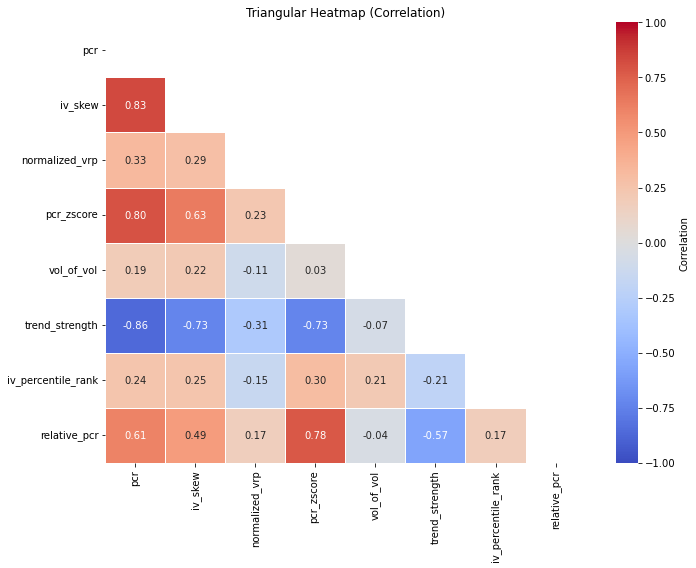

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming df is your DataFrame
# For example: df = pd.read_csv('your_data.csv')

# Compute the correlation matrix
corr = features.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the filtered correlation values.
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Triangular Heatmap (Correlation)")
plt.tight_layout()
plt.show()

In [7]:
size = int(len(df) * 0.8)
X_train = features.iloc[:size, :]
X_test = features.iloc[size:, :]
train_price = price.iloc[:size]
test_price = price.iloc[size:]

## Standard HMM

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm.notebook import tqdm
from sklearn.metrics import silhouette_score
from hmmlearn import hmm

def fit_hmm_and_visualize(X_train, X_test, train_price, test_price, columns, n_regimes=3):
    """
    Fits an HMM model on specified columns of data and visualizes the regimes.
    
    Parameters:
    -----------
    X_train : pandas.DataFrame
        Training data containing the feature columns
    X_test : pandas.DataFrame
        Test data containing the feature columns
    train_price : pandas.Series or array-like
        Price data for the training period
    test_price : pandas.Series or array-like
        Price data for the test period
    columns : str or list of str
        The name(s) of the column(s) to use for HMM training
    n_regimes : int, default=3
        Number of regimes/states to identify
        
    Returns:
    --------
    dict
        Dictionary containing model, states, and performance metrics
    """
    # Convert single column name to list for consistent handling
    if isinstance(columns, str):
        columns = [columns]
    
    # Create feature name for display
    feature_name = ", ".join(columns)
    
    # Step 1: Prepare the data
    # Extract the specified columns from X_train for training
    X_train_hmm = X_train[columns].values
    
    # Step 2: Train the HMM model
    model = hmm.GaussianHMM(n_components=n_regimes, covariance_type="full", n_iter=1000, random_state=42)
    model.fit(X_train_hmm)

    # Step 3: Get the predicted states/regimes for train data
    train_states = model.predict(X_train_hmm)

    # Step 4: Get the predicted states/regimes for test data
    X_test_hmm = X_test[columns].values
    test_states = model.predict(X_test_hmm)

    # Step 5: Compute model evaluation metrics
    # Log likelihood
    log_likelihood = model.score(X_train_hmm)

    # Silhouette score for training data
    silhouette = silhouette_score(X_train_hmm, train_states)

    # Step 6: Calculate returns by regime
    train_returns_by_regime = {}
    for regime in np.unique(train_states):
        regime_returns = X_train.loc[train_states == regime, 'Returns']
        train_returns_by_regime[regime] = {
            'mean': regime_returns.mean(),
            'std': regime_returns.std(),
            'count': len(regime_returns)
        }

    test_returns_by_regime = {}
    for regime in np.unique(test_states):
        regime_returns = X_test.loc[test_states == regime, 'Returns']
        test_returns_by_regime[regime] = {
            'mean': regime_returns.mean(),
            'std': regime_returns.std(),
            'count': len(regime_returns)
        }

    # Step 7: Create visualizations
    plt.figure(figsize=(16, 12))

    # Plot 1: Training data with regimes
    plt.subplot(2, 1, 1)

    # Convert train_price to a Series if it's not already one
    if not isinstance(train_price, pd.Series):
        train_price = pd.Series(train_price, index=X_train.index)

    # Get the datetime index
    dates = train_price.index

    # First plot the full price series as a line
    plt.plot(dates, train_price, 'k-', alpha=0.3)

    # Then plot each regime's points on top
    for i, regime in enumerate(np.unique(train_states)):
        # Create a mask for the current regime
        mask = train_states == regime
        
        # Use boolean indexing with the mask to get dates and prices for this regime
        regime_dates = dates[mask]
        regime_prices = train_price[mask]
        
        plt.plot(regime_dates, regime_prices, 'o', markersize=4, label=f'Regime {regime}')

    plt.title(f'Training Data with HMM Regimes (Features: {feature_name})\nLog Likelihood: {log_likelihood:.2f}, Silhouette Score: {silhouette:.2f}')
    plt.ylabel('Price')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)

    # Add regime statistics as text
    for i, regime in enumerate(train_returns_by_regime.keys()):
        stats = train_returns_by_regime[regime]
        plt.annotate(
            f"Regime {regime}: Return = {stats['mean']:.4f}, Std = {stats['std']:.4f}, N = {stats['count']}",
            xy=(0.02, 0.95 - i*0.05),
            xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
        )

    # Plot 2: Test data with regimes
    plt.subplot(2, 1, 2)

    # Convert test_price to a Series if it's not already one
    if not isinstance(test_price, pd.Series):
        test_price = pd.Series(test_price, index=X_test.index)

    # Get the datetime index
    test_dates = test_price.index

    # First plot the full price series as a line
    plt.plot(test_dates, test_price, 'k-', alpha=0.3)

    # Then plot each regime's points on top
    for i, regime in enumerate(np.unique(test_states)):
        # Create a mask for the current regime
        mask = test_states == regime
        
        # Use boolean indexing with the mask to get dates and prices for this regime
        regime_dates = test_dates[mask]
        regime_prices = test_price[mask]
        
        plt.plot(regime_dates, regime_prices, 'o', markersize=4, label=f'Regime {regime}')

    plt.title(f'Test Data with HMM Regimes (Features: {feature_name})')
    plt.ylabel('Price')
    plt.xlabel('Time')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)

    # Add regime statistics as text
    for i, regime in enumerate(test_returns_by_regime.keys()):
        stats = test_returns_by_regime[regime]
        plt.annotate(
            f"Regime {regime}: Return = {stats['mean']:.4f}, Std = {stats['std']:.4f}, N = {stats['count']}",
            xy=(0.02, 0.95 - i*0.05),
            xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
        )

    plt.tight_layout()
    plt.show()

    # Print detailed regime statistics
    print(f"\n=== HMM Analysis using features: {feature_name} ===")
    print("\n=== Training Data Regime Statistics ===")
    for regime, stats in train_returns_by_regime.items():
        print(f"Regime {regime}:")
        print(f"  Mean Return: {stats['mean']:.6f}")
        print(f"  Std Dev: {stats['std']:.6f}")
        print(f"  Count: {stats['count']}")
        print(f"  Percentage: {stats['count']/len(train_states)*100:.2f}%")

    print("\n=== Test Data Regime Statistics ===")
    for regime, stats in test_returns_by_regime.items():
        print(f"Regime {regime}:")
        print(f"  Mean Return: {stats['mean']:.6f}")
        print(f"  Std Dev: {stats['std']:.6f}")
        print(f"  Count: {stats['count']}")
        print(f"  Percentage: {stats['count']/len(test_states)*100:.2f}%")

    # Additional analysis: Transition matrix
    print("\n=== Transition Matrix ===")
    print(pd.DataFrame(model.transmat_, 
                    index=[f"From Regime {i}" for i in range(model.n_components)],
                    columns=[f"To Regime {i}" for i in range(model.n_components)]))

    # Expected duration in each state
    expected_duration = -1.0 / np.log(np.diag(model.transmat_))
    print("\n=== Expected Regime Duration ===")
    for i, duration in enumerate(expected_duration):
        print(f"Regime {i}: {duration:.2f} time periods")
        
    # Return results for further analysis if needed
    results = {
        'model': model,
        'train_states': train_states,
        'test_states': test_states,
        'log_likelihood': log_likelihood,
        'silhouette': silhouette,
        'train_returns_by_regime': train_returns_by_regime,
        'test_returns_by_regime': test_returns_by_regime
    }
    
    return results

def run_all_feature_combinations(df, features, n_regimes=3, test_size=0.2, plot_top=5):
    """
    Runs HMM models on all possible combinations of features.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing all features and a 'Returns' column
    features : pandas.DataFrame
        DataFrame containing just the features to be used in combinations
    n_regimes : int, default=3
        Number of regimes to identify with HMM
    test_size : float, default=0.2
        Proportion of data to use for testing
    plot_top : int, default=5
        Number of top models to plot
        
    Returns:
    --------
    dict
        Dictionary of results for all feature combinations
    """
    # Ensure 'Returns' column exists in df
    if 'returns_20d' in df.columns and 'Returns' not in df.columns:
        df['Returns'] = df['returns_20d']
    elif 'Returns' not in df.columns:
        raise ValueError("DataFrame must contain either 'Returns' or 'returns_20d' column")
    
    # Ensure we have a datetime index for plotting
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'date' in df.columns:
            df = df.set_index('date')
        else:
            print("Warning: No datetime index found. Using row numbers instead.")
    
    # Split the data into training and testing sets
    split_idx = int(len(df) * (1 - test_size))
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    # Get price data (use BTC price if available, otherwise use index)
    if 'btc_price' in df.columns:
        train_price = train_df['btc_price']
        test_price = test_df['btc_price']
    else:
        print("Warning: No price column found. Using a placeholder.")
        train_price = pd.Series(np.arange(len(train_df)), index=train_df.index)
        test_price = pd.Series(np.arange(len(test_df)), index=test_df.index)
    
    # Get all feature columns from the features dataframe
    all_features = features.columns.tolist()
    
    # Make sure we have the features columns in our train and test dataframes
    for col in all_features:
        if col not in train_df.columns:
            train_df[col] = features.loc[train_df.index, col]
        if col not in test_df.columns:
            test_df[col] = features.loc[test_df.index, col]
    
    # Create all possible combinations of features
    all_combinations = []
    for i in range(1, len(all_features) + 1):
        all_combinations.extend(combinations(all_features, i))
    
    print(f"Testing {len(all_combinations)} feature combinations...")
    
    # Dictionary to store results
    results = {}
    
    # Run HMM on each combination with progress bar
    for i, feature_combo in enumerate(tqdm(all_combinations, desc="Evaluating HMM Models")):
        # Display current model info
        feature_str = ", ".join(feature_combo)
        tqdm.write(f"Model {i+1}/{len(all_combinations)}: Features = {feature_str}")
        
        try:
            # Run the HMM model and visualize
            model_results = fit_hmm_and_visualize(
                X_train=train_df,
                X_test=test_df,
                train_price=train_price,
                test_price=test_price,
                columns=list(feature_combo),
                n_regimes=n_regimes
            )
            
            # Store results for this feature combination
            results[feature_str] = {
                'silhouette': model_results['silhouette'],
                'log_likelihood': model_results['log_likelihood'],
                'train_returns_by_regime': model_results['train_returns_by_regime'],
                'test_returns_by_regime': model_results['test_returns_by_regime'],
                'model': model_results['model'],
                'features': feature_combo
            }
            
        except Exception as e:
            tqdm.write(f"Error with features {feature_str}: {str(e)}")
            continue
    
    # Create a summary DataFrame of model performance
    summary = []
    for feature_str, res in results.items():
        # Calculate return differentiation (difference between best and worst regime returns)
        train_returns = [stats['mean'] for stats in res['train_returns_by_regime'].values()]
        train_return_diff = max(train_returns) - min(train_returns)
        
        test_returns = [stats['mean'] for stats in res['test_returns_by_regime'].values()]
        test_return_diff = max(test_returns) if test_returns else 0
        
        summary.append({
            'features': feature_str,
            'silhouette': res['silhouette'],
            'log_likelihood': res['log_likelihood'],
            'train_return_diff': train_return_diff,
            'test_return_diff': test_return_diff,
            'n_features': len(res['features'])
        })
    
    summary_df = pd.DataFrame(summary)
    
    # Sort by both return differentiation and silhouette score
    summary_df['combined_score'] = (
        summary_df['silhouette'] + 
        summary_df['train_return_diff'] * 100  # Scale return diff to be comparable to silhouette
    )
    summary_df = summary_df.sort_values('combined_score', ascending=False)
    
    print("\n==== Top Feature Combinations ====")
    print(summary_df.head(10).to_string())
    
    # Plot the top models again if requested
    if plot_top > 0:
        for idx, row in summary_df.head(plot_top).iterrows():
            feature_combo = results[row['features']]['features']
            print(f"\nRe-plotting top model {row['features']}...")
            fit_hmm_and_visualize(
                X_train=train_df,
                X_test=test_df,
                train_price=train_price,
                test_price=test_price,
                columns=list(feature_combo),
                n_regimes=n_regimes
            )
    
    return {'results': results, 'summary': summary_df}

# Example usage
def run_hmm_on_btc_options(df, features, n_regimes=3):
    """
    Main function to run the HMM analysis on BTC options data.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Original dataframe with returns and price data
    features : pandas.DataFrame
        DataFrame containing only the selected features for analysis
    n_regimes : int, default=3
        Number of regimes to identify
    
    Returns:
    --------
    dict
        Results of the analysis
    """
    # Print information about the features
    print(f"Running HMM analysis with {len(features.columns)} features:")
    print(f"Features being used: {features.columns.tolist()}")
    print(f"Number of regimes: {n_regimes}")
    print(f"Total data points: {len(features)}")
    
    # Calculate total number of feature combinations
    total_combinations = 0
    for i in range(1, len(features.columns) + 1):
        total_combinations += len(list(combinations(features.columns, i)))
    print(f"Total feature combinations to evaluate: {total_combinations}")
    
    # Check for missing values
    missing_values = features.isnull().sum().sum()
    if missing_values > 0:
        print(f"Warning: {missing_values} missing values found in features. These will be dropped.")
        features = features.dropna()
        print(f"Remaining data points after dropping missing values: {len(features)}")
    
    # Run the analysis
    results = run_all_feature_combinations(
        df=df,
        features=features,
        n_regimes=n_regimes,
        test_size=0.2,
        plot_top=5
    )
    
    # Save results to CSV
    results['summary'].to_csv('hmm_btc_options_results.csv')
    print("\nAnalysis complete. Results saved to 'hmm_btc_options_results.csv'")
    
    return results

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from tqdm.notebook import tqdm

# 1. First calculate the features
def calculate_selected_features(df):
    """
    Calculate only the selected features that can be properly derived from 
    available data and return them in a new DataFrame.
    """
    # Create a copy of the dataframe to avoid modifying the original
    df_copy = df.copy()
    
    # Create an empty DataFrame to store our selected features
    features = pd.DataFrame(index=df.index)
    
    # Add existing features that we want to include
    features['pcr'] = df['pcr']
    features['iv_skew'] = df['iv_skew']
    
    # Calculate Volatility Risk Premium (VRP) if not already in df
    if 'vrp' not in df.columns:
        df_copy['vrp'] = df['iv'] - df['volatility']
        
    # 1. Normalized VRP
    if 'normalized_vrp' not in df.columns:
        features['normalized_vrp'] = df_copy['vrp'] / df['volatility']
    else:
        features['normalized_vrp'] = df['normalized_vrp']
    
    # 2. PCR Z-Score
    if 'pcr_zscore' not in df.columns:
        pcr_mean = df['pcr'].rolling(window=60).mean()
        pcr_std = df['pcr'].rolling(window=60).std()
        features['pcr_zscore'] = (df['pcr'] - pcr_mean) / pcr_std
    else:
        features['pcr_zscore'] = df['pcr_zscore']
    
    # 3. Volatility of Volatility
    if 'vol_of_vol' not in df.columns:
        features['vol_of_vol'] = df['iv'].rolling(window=20).std()
    else:
        features['vol_of_vol'] = df['vol_of_vol']
    
    # 4. Trend Strength Indicator
    if 'trend_strength' not in df.columns:
        def rolling_trend_strength(price_series, window=20):
            result = pd.Series(index=price_series.index, dtype=float)
            for i in range(window-1, len(price_series)):
                y = price_series.iloc[i-window+1:i+1].values
                x = np.arange(window)
                correlation = np.corrcoef(x, y)[0, 1]
                result.iloc[i] = correlation
            return result
        
        features['trend_strength'] = rolling_trend_strength(df['btc_price'])
    else:
        features['trend_strength'] = df['trend_strength']
    
    # 5. IV Percentile Rank
    if 'iv_percentile_rank' not in df.columns:
        def percentile_rank(series, window=252):
            result = pd.Series(index=series.index, dtype=float)
            for i in range(window-1, len(series)):
                window_data = series.iloc[i-window+1:i+1]
                current_value = series.iloc[i]
                result.iloc[i] = sum(window_data <= current_value) / window * 100
            return result
        
        features['iv_percentile_rank'] = percentile_rank(df['iv'])
    else:
        features['iv_percentile_rank'] = df['iv_percentile_rank']
    
    # 6. Relative PCR
    if 'relative_pcr' not in df.columns:
        if 'pcr_20d_ma' not in df.columns:
            pcr_20d_ma = df['pcr'].rolling(window=20).mean()
        else:
            pcr_20d_ma = df['pcr_20d_ma']
        
        features['relative_pcr'] = df['pcr'] / pcr_20d_ma
    else:
        features['relative_pcr'] = df['relative_pcr']
    
    # Note: We're removing vol_term_structure since it's 100% correlated with normalized_vrp
    # Just keeping vol_term_structure would duplicate information
    
    # Drop any NaN values that might have been introduced by rolling calculations
    features = features.dropna()
    
    return features

# Execute this code to run the HMM model with 3 regimes

# Step 1: Make sure 'Returns' column exists in your dataframe
if 'Returns' not in df.columns and 'returns_20d' in df.columns:
    df['Returns'] = df['returns_20d']

# Step 4: Run the HMM model with 3 regimes
results = run_hmm_on_btc_options(df, features, n_regimes=3)

# Step 5: Extract the best feature combination from results
best_combo = results['summary'].iloc[0]['features']
print(f"\nBest feature combination: {best_combo}")

# Step 6: Get the performance metrics for the best model
best_silhouette = results['summary'].iloc[0]['silhouette']
best_return_diff = results['summary'].iloc[0]['train_return_diff']
print(f"Best model silhouette score: {best_silhouette:.4f}")
print(f"Best model return differentiation: {best_return_diff:.4f}")

# Optional: Analyze regime characteristics of best model
best_model_key = results['summary'].iloc[0]['features']
best_model_results = results['results'][best_model_key]

print("\nRegime Characteristics for Best Model:")
for regime, stats in best_model_results['train_returns_by_regime'].items():
    print(f"Regime {regime}:")
    print(f"  Mean Return: {stats['mean']:.6f}")
    print(f"  Std Dev: {stats['std']:.6f}")
    print(f"  Count: {stats['count']}")
    print(f"  Percentage: {stats['count']/sum([s['count'] for s in best_model_results['train_returns_by_regime'].values()])*100:.2f}%")

# Optional: Plot the regimes over time for the best model
# Already done in the run_hmm_on_btc_options function

Running HMM analysis with 8 features:
Features being used: ['pcr', 'iv_skew', 'normalized_vrp', 'pcr_zscore', 'vol_of_vol', 'trend_strength', 'iv_percentile_rank', 'relative_pcr']
Number of regimes: 3
Total data points: 935
Total feature combinations to evaluate: 255


KeyError: "[Timestamp('2021-01-01 02:00:00'), Timestamp('2021-01-02 02:00:00'), Timestamp('2021-01-03 02:00:00'), Timestamp('2021-01-04 02:00:00'), Timestamp('2021-01-05 02:00:00'), Timestamp('2021-01-06 02:00:00'), Timestamp('2021-01-07 02:00:00'), Timestamp('2021-01-08 02:00:00'), Timestamp('2021-01-09 02:00:00'), Timestamp('2021-01-10 02:00:00'), Timestamp('2021-01-11 02:00:00'), Timestamp('2021-01-12 02:00:00'), Timestamp('2021-01-13 02:00:00'), Timestamp('2021-01-14 02:00:00'), Timestamp('2021-01-15 02:00:00'), Timestamp('2021-01-16 02:00:00'), Timestamp('2021-01-17 02:00:00'), Timestamp('2021-01-18 02:00:00'), Timestamp('2021-01-19 02:00:00'), Timestamp('2021-01-20 02:00:00'), Timestamp('2021-01-21 02:00:00'), Timestamp('2021-01-22 02:00:00'), Timestamp('2021-01-23 02:00:00'), Timestamp('2021-01-24 02:00:00'), Timestamp('2021-01-25 02:00:00'), Timestamp('2021-01-26 02:00:00'), Timestamp('2021-01-27 02:00:00'), Timestamp('2021-01-28 02:00:00'), Timestamp('2021-01-29 02:00:00'), Ti